# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

Additional Information

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed. 

There are four datasets: 
1) bank-additional-full.csv with all examples (41188) and 20 inputs, ordered by date (from May 2008 to November 2010), very close to the data analyzed in [Moro et al., 2014]
2) bank-additional.csv with 10% of the examples (4119), randomly selected from 1), and 20 inputs.
3) bank-full.csv with all examples and 17 inputs, ordered by date (older version of this dataset with less inputs). 
4) bank.csv with 10% of the examples and 17 inputs, randomly selected from 3 (older version of this dataset with less inputs). 
The smallest datasets are provided to test more computationally demanding machine learning algorithms (e.g., SVM). 

The classification goal is to predict if the client will subscribe (yes/no) a term deposit (variable y).

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [216]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn import datasets

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)

In [62]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [64]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [67]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [70]:
# Eliminar columnas
del df['job']
del df['education']
del df['default']
del df['emp.var.rate']
del df['cons.price.idx']
del df['cons.conf.idx']
del df['euribor3m']
del df['nr.employed']

In [72]:
df.head()

,age,marital,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,56,married,no,no,telephone,may,mon,261,1,999,0,nonexistent,no
1,57,married,no,no,telephone,may,mon,149,1,999,0,nonexistent,no
2,37,married,yes,no,telephone,may,mon,226,1,999,0,nonexistent,no
3,40,married,no,no,telephone,may,mon,151,1,999,0,nonexistent,no
4,56,married,no,yes,telephone,may,mon,307,1,999,0,nonexistent,no


In [74]:
# Procesamiento
df = df[df['marital'] != 'unknown'].copy()
df = df[df['housing'] != 'unknown'].copy()

In [76]:
df['housing'] = df['housing'].replace(['yes', 'no'], [1, 0])
df['loan'] = df['loan'].replace(['yes', 'no'], [1, 0])
df['contact'] = df['contact'].replace(['cellular', 'telephone'], [1, -1])
df['month'] = df['month'].replace(['may', 'jul', 'aug', 'jun', 'nov', 'apr', 'oct', 'sep', 'mar', 'dec'], [5, 7, 8, 6, 11, 4, 10, 9, 3, 12])
df['day_of_week'] = df['day_of_week'].replace(['thu', 'mon', 'wed', 'tue', 'fri'], [4, 1, 3, 2, 5])
df['y'] = df['y'].replace(['no', 'yes'], [0, 1])

C:\Users\Dev\AppData\Local\Temp\ipykernel_11828\229496196.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['housing'] = df['housing'].replace(['yes', 'no'], [1, 0])
C:\Users\Dev\AppData\Local\Temp\ipykernel_11828\229496196.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan'] = df['loan'].replace(['yes', 'no'], [1, 0])
C:\Users\Dev\AppData\Local\Temp\ipykernel_11828\229496196.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expl

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [86]:
# Rebalance the data because is 89% No and 11% Yes
# Suponiendo que 'df' es tu DataFrame original y 'y' es la columna objetivo
class_0 = df[df['y'] == 0]  # Clase mayoritaria (35K)
class_1 = df[df['y'] == 1]  # Clase minoritaria (4K)

# 1. Obtener el tamaño de la clase minoritaria
min_count = min(len(class_0), len(class_1))

# 2. Submuestrear la clase mayoritaria (undersampling)
class_0_undersampled = class_0.sample(n=min_count, random_state=42)

# 3. Combinar con la clase minoritaria (ya balanceada)
balanced_df = pd.concat([class_0_undersampled, class_1])

# 4. Mezclar los datos para evitar sesgos en el orden
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 5. Verificar resultados
print("Original dataset:")
print(df['y'].value_counts())

print("\nBalanced dataset (undersampling):")
print(balanced_df['y'].value_counts())

Original dataset:
y
0    35598
1     4521
Name: count, dtype: int64

Balanced dataset (undersampling):
y
0    4521
1    4521
Name: count, dtype: int64


In [94]:
df = balanced_df.copy()

<Axes: ylabel='y'>

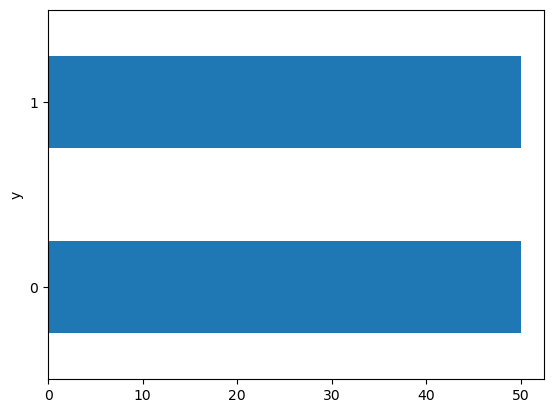

In [106]:
(df['y'].value_counts(normalize=True) * 100).plot(kind='barh')

In [108]:
# Create Dummies to Categorical
df = pd.get_dummies(df)

In [110]:
df.head()

,age,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,y,marital_divorced,marital_married,marital_single,poutcome_failure,poutcome_nonexistent,poutcome_success
0,35,0,0,-1,5,4,297,1,999,0,0,False,False,True,False,True,False
1,64,1,1,1,8,5,146,1,999,1,0,False,True,False,True,False,False
2,36,0,0,1,8,1,54,5,999,0,0,False,True,False,False,True,False
3,45,1,0,1,4,5,654,1,999,0,0,False,True,False,False,True,False
4,56,0,0,1,5,1,540,1,999,1,1,False,True,False,True,False,False


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9042 entries, 0 to 9041
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   9042 non-null   int64
 1   housing               9042 non-null   int64
 2   loan                  9042 non-null   int64
 3   contact               9042 non-null   int64
 4   month                 9042 non-null   int64
 5   day_of_week           9042 non-null   int64
 6   duration              9042 non-null   int64
 7   campaign              9042 non-null   int64
 8   pdays                 9042 non-null   int64
 9   previous              9042 non-null   int64
 10  y                     9042 non-null   int64
 11  marital_divorced      9042 non-null   bool 
 12  marital_married       9042 non-null   bool 
 13  marital_single        9042 non-null   bool 
 14  poutcome_failure      9042 non-null   bool 
 15  poutcome_nonexistent  9042 non-null   bool 
 16  poutco

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

## Data Preparation

In [115]:
y = df.pop('y')
X = df

In [117]:
# Split the data Note- Is first the split before the Scaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [119]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

## Modeling

### -- KNN

In [138]:
# Optimize the model
k = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
accuracy = []
error = []

accuracy_train = []
error_train = []

for i in k:
    clf_ = KNeighborsClassifier(n_neighbors=i).fit(X_train, y_train)
    preds = clf_.predict(X_test)

    accuracy_temp = accuracy_score(y_test, preds) * 100
    accuracy.append(accuracy_temp)
    error.append(100 - accuracy_temp)

    preds_train = clf_.predict(X_train)
    accuracy_temp_train = accuracy_score(y_train, preds_train) * 100
    accuracy_train.append(accuracy_temp_train)
    error_train.append(100 - accuracy_temp_train)

In [140]:
bias_variance = pd.DataFrame(k)
bias_variance.columns = ['k']
bias_variance['accuracy'] = accuracy
bias_variance['error'] = error
bias_variance['accuracy_train'] = accuracy_train
bias_variance['error_train'] = error_train

Text(0, 0.5, 'error')

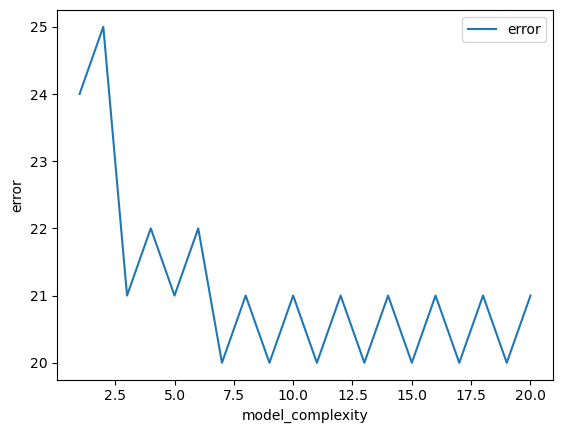

In [142]:
ax = bias_variance[['k', 'error']].round().set_index('k').plot()
ax.set_xlabel('model_complexity')
ax.set_ylabel('error')

In [146]:
# Neighbors winner:
K = 7
knn_clf = KNeighborsClassifier(n_neighbors=K).fit(X_train, y_train)
y_pred = knn_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7950608182823443

In [148]:
# Confussion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[1128,  231],
       [ 325, 1029]], dtype=int64)

-----

## Logistic Regression

In [163]:
# Rangos de hiperparámetros
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
accuracy_test = []
accuracy_train = []

for C in C_values:
    # Entrenar modelo
    model = LogisticRegression(C=C, random_state=42, max_iter=1000).fit(X_train, y_train)
    
    # Predecir en test y train
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    # Calcular accuracy
    accuracy_test.append(accuracy_score(y_test, y_pred_test) * 100)
    accuracy_train.append(accuracy_score(y_train, y_pred_train) * 100)

# Resultados
print("C values:", C_values)
print("Test Accuracy:", accuracy_test)
print("Train Accuracy:", accuracy_train)

C values: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
Test Accuracy: [79.02690748249171, 80.53814964983414, 80.64872834500552, 80.64872834500552, 80.68558791006267, 80.68558791006267, 80.68558791006267]
Train Accuracy: [78.46421235582241, 79.80723653025754, 79.88623795228314, 79.88623795228314, 79.88623795228314, 79.88623795228314, 79.88623795228314]


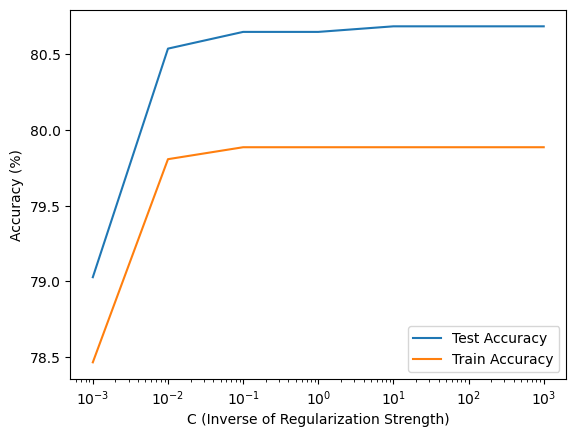

In [165]:
plt.plot(C_values, accuracy_test, label='Test Accuracy')
plt.plot(C_values, accuracy_train, label='Train Accuracy')
plt.xscale('log')  # Escala logarítmica para C
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [173]:
# Neighbors winner:
C = 1000
lr_clf = LogisticRegression(C=C, random_state=42, max_iter=1000).fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8068558791006266

In [175]:
# Confussion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[1154,  205],
       [ 319, 1035]], dtype=int64)

## Decision Tree

In [153]:
# Optimize the model
depth = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
accuracy = []
error = []

accuracy_train = []
error_train = []

for i in depth:
    clf_ = DecisionTreeClassifier(max_depth=i, random_state=42).fit(X_train, y_train)
    preds = clf_.predict(X_test)

    accuracy_temp = accuracy_score(y_test, preds) * 100
    accuracy.append(accuracy_temp)
    error.append(100 - accuracy_temp)

    preds_train = clf_.predict(X_train)
    accuracy_temp_train = accuracy_score(y_train, preds_train) * 100
    accuracy_train.append(accuracy_temp_train)
    error_train.append(100 - accuracy_temp_train)

In [155]:
bias_variance = pd.DataFrame(k)
bias_variance.columns = ['k']
bias_variance['accuracy'] = accuracy
bias_variance['error'] = error
bias_variance['accuracy_train'] = accuracy_train
bias_variance['error_train'] = error_train

Text(0, 0.5, 'error')

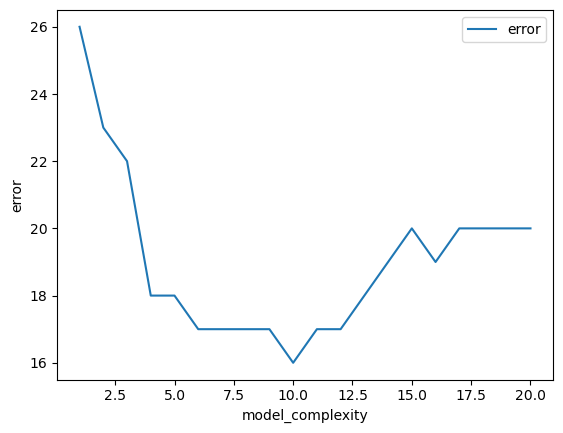

In [157]:
ax = bias_variance[['k', 'error']].round().set_index('k').plot()
ax.set_xlabel('model_complexity')
ax.set_ylabel('error')

In [205]:
# Decision winner:
depth = 6
dt_clf = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
y_pred = dt_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8293402137854773

In [207]:
# Confussion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[1013,  346],
       [ 117, 1237]], dtype=int64)

## SUPPORT VECTOR MACHINE

In [177]:
kernels = ['linear', 'rbf', 'poly']
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Diccionarios para almacenar resultados
results_test = {kernel: [] for kernel in kernels}
results_train = {kernel: [] for kernel in kernels}

for kernel in kernels:
    for C in C_values:
        model = SVC(C=C, kernel=kernel, random_state=42).fit(X_train, y_train)
        
        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)
        
        results_test[kernel].append(accuracy_score(y_test, y_pred_test) * 100)
        results_train[kernel].append(accuracy_score(y_train, y_pred_train) * 100)

# Mostrar resultados
for kernel in kernels:
    print(f"\nKernel: {kernel}")
    print("C values:", C_values)
    print("Test Accuracy:", results_test[kernel])
    print("Train Accuracy:", results_train[kernel])


Kernel: linear
C values: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
Test Accuracy: [77.84740140066347, 79.87467747880575, 79.94839660892, 80.0589753040914, 80.0589753040914, 80.0589753040914, 80.0589753040914]
Train Accuracy: [77.87960183283299, 79.38062885131933, 79.601832832991, 79.64923368620636, 79.63343340180124, 79.63343340180124, 79.58603254858588]

Kernel: rbf
C values: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
Test Accuracy: [49.907851087357166, 74.2351640250645, 82.15997051234795, 82.89716181349061, 82.86030224843347, 81.6439366015481, 80.46443051971987]
Train Accuracy: [50.0395007110128, 75.90456628219307, 82.00347606256912, 84.10491388845, 86.38015484278718, 88.97140148522674, 91.78385210933797]

Kernel: poly
C values: [0.001, 0.01, 0.1, 1, 10, 100, 1000]
Test Accuracy: [59.38075930704018, 64.09878363435311, 77.81054183560634, 81.82823442683377, 81.31220051603391, 80.94360486546259, 80.64872834500552]
Train Accuracy: [59.23526623479223, 63.73834729025123, 78.14820666772002, 83.378100

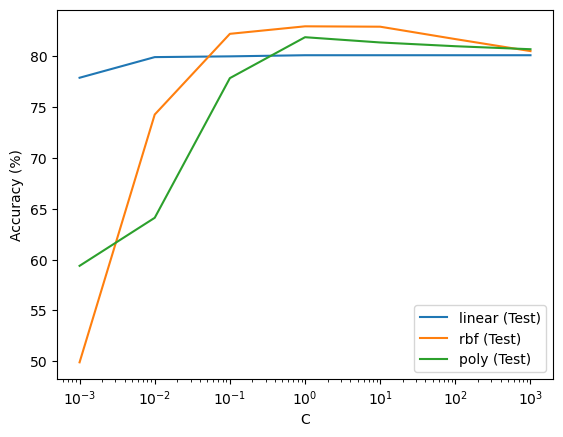

In [179]:
for kernel in kernels:
    plt.plot(C_values, results_test[kernel], label=f'{kernel} (Test)')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [185]:
kernel = 'rbf'
c = 1
svm_clf = SVC(kernel=kernel, C=c, random_state=42).fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.828971618134906

In [187]:
# Confussion matrix
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[1120,  239],
       [ 225, 1129]], dtype=int64)

### Problem 9: Score the Model

What is the accuracy of your model?

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

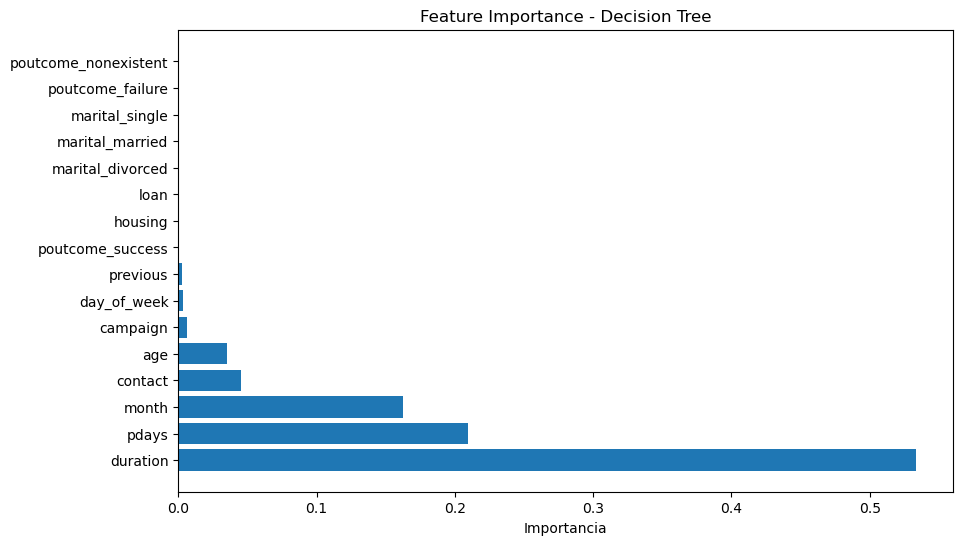

In [209]:
# Obtener importancia de características
feature_importance = pd.DataFrame({
    'Feature': df.columns.tolist(),
    'Importance': dt_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importancia')
plt.title('Feature Importance - Decision Tree')
plt.show()

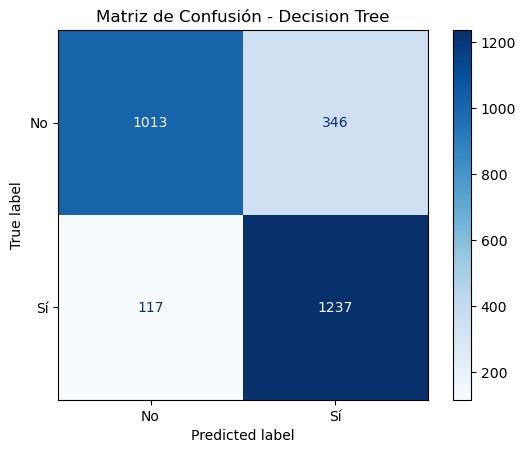

In [214]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Sí'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Decision Tree')
plt.show()

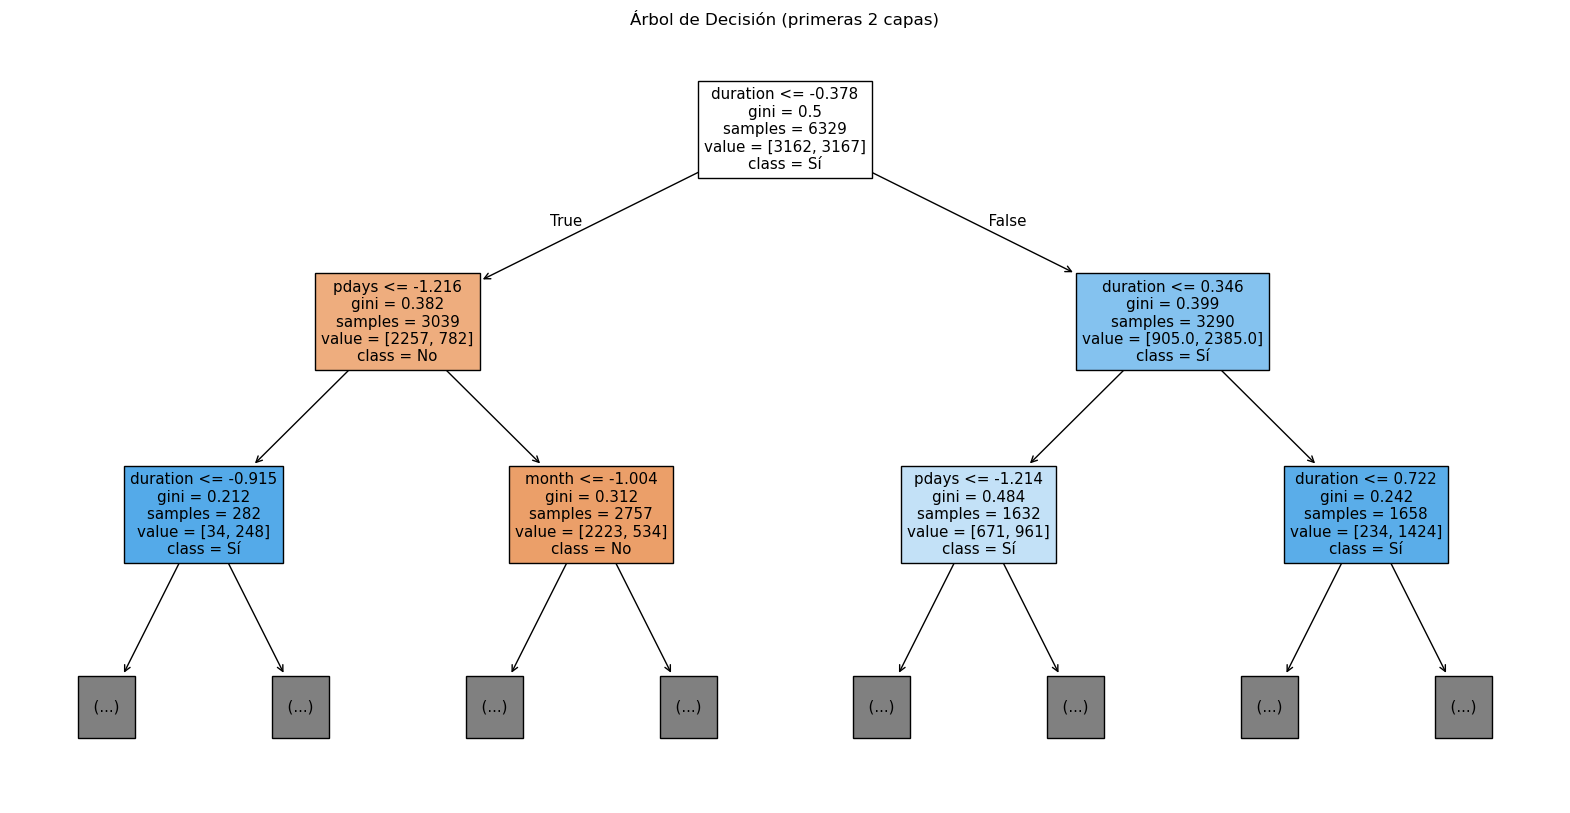

In [221]:
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=df.columns, class_names=['No', 'Sí'], filled=True, max_depth=2)
plt.title('Árbol de Decisión (primeras 2 capas)')
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

## Outcomes marketing

1. **Key Variables**:
- Focus campaigns on customers with high call duration and prior success.
- Discard variables with an importance <1% (e.g., 'loan', 'day_of_week').

2. **Common Mistakes**:
- False Positives: Optimize the sales script to avoid unrealistic promises.
- False Negatives: Re-contact customers misclassified as 'No'.

3. **Segmentation**:
- Prioritize singles ('marital_single=True') if they have a higher success rate.
- Adjust messages for married customers ('marital_married') if their accuracy is low.

4. **Monitoring**:
- Review the distribution of duration and poutcome_success monthly.

- Retrain the model with new data every quarter

##### Questions